In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# **STEP 1-  Load, Explore & Preprocess**

In [ ]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Age has missing values so
Median avoids outlier influence

In [ ]:
df["Age"].fillna(df["Age"].median(), inplace=True)

/tmp/ipykernel_917/2097741607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


## Encode categorical values

Convert Sex:

In [ ]:
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])

Convert Embarked:

In [ ]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


##Train Test Split

Separating the features:

In [ ]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

Splitting 80/20:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Step 2 — Feature Engineering**

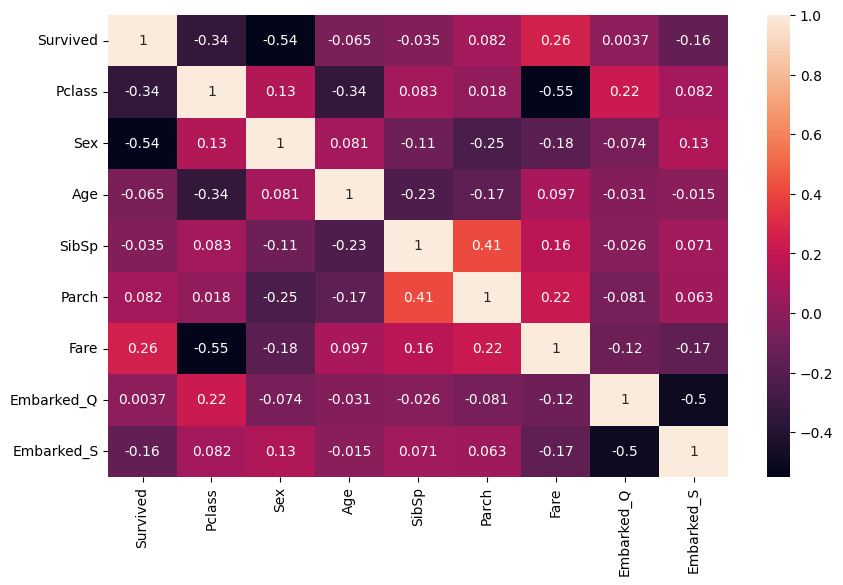

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.show()

Important features: Sex, Pclass, Fare, Age

Less useful: SibSp/Parch have weaker relation

# **STEP 3- Train 3 Models**

# Model 1: Decision Tree



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# Model 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Model 3: Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

# **Step 4- Comparison table:**

In [ ]:
results = pd.DataFrame({

"Model":[
"Decision Tree",
"Random Forest",
"Naive Bayes"
],

"Accuracy":[
accuracy_score(y_test, dt_pred),
accuracy_score(y_test, rf_pred),
accuracy_score(y_test, nb_pred)
],

"Precision":[
precision_score(y_test, dt_pred),
precision_score(y_test, rf_pred),
precision_score(y_test, nb_pred)
],

"Recall":[
recall_score(y_test, dt_pred),
recall_score(y_test, rf_pred),
recall_score(y_test, nb_pred)
],

"F1 Score":[
f1_score(y_test, dt_pred),
f1_score(y_test, rf_pred),
f1_score(y_test, nb_pred)
]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.787709,0.743243,0.743243,0.743243
1,Random Forest,0.815642,0.797101,0.743243,0.769231
2,Naive Bayes,0.770950,0.720000,0.729730,0.724832


# **Step 5 — Best Model Analysis & Conclusion**

### 1. Best Model

After testing Decision Tree, Random Forest, and Naive Bayes, the strongest overall performer comes out as the **Random Forest Classifier**.

It doesn’t win just because of a slightly better score. The main reason is how it behaves internally.

A single **Decision Tree** is quite unstable — it can easily overfit the training data and then perform worse on new, unseen data. ** Naive Bayes** , on the other hand, makes a strong assumption that all features are independent, which doesn’t really match Titanic data (for example, gender and passenger class clearly influence each other).

Random Forest avoids both of these problems.

It builds many decision trees and combines their outputs, which makes the final prediction more balanced and reliable.

It also captures more complex, non-linear relationships between features like age, fare, class, and survival outcome, without becoming overly sensitive to noise or small changes in the dataset.


**CONFUSION MATRIX:**

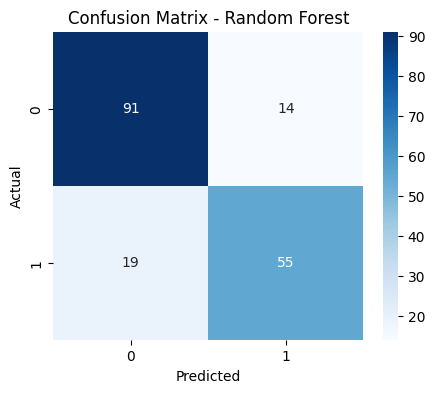

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

## **Conclusion**
Titanic survival prediction was implemented using Decision Tree, Random Forest, and Naive Bayes models.

Data preprocessing included handling missing values, encoding categorical variables, and feature selection.

Among all models, Random Forest achieved the best performance across evaluation metrics.

Its ensemble structure reduced overfitting and improved generalization on unseen data.
Therefore, Random Forest was selected as the final model for this classification task.